# Deep Learning Architectures: ResNet and VGG

This notebook explores the implementation and comparison of Residual Networks (ResNet) and VGG architectures for image classification tasks using TensorFlow and Keras.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
from tensorflow.keras.datasets import mnist

### ResNet on MNIST Dataset

This section demonstrates the implementation of a basic ResNet model on the MNIST dataset to classify handwritten digits.

#### Data Loading and Preprocessing

First, we load the MNIST dataset, normalize pixel values, reshape the images to include a channel dimension, and convert labels to one-hot encoding for training a neural network.

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape input data to include channel dimension (28x28x1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Convert labels to categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### ResNet Model Definition

Here, we define the `residual_block` function, which forms the core of our ResNet architecture. This block includes two convolutional layers and a skip connection, allowing the network to learn residual functions. The `build_resnet` function then assembles these blocks into a complete model.

In [ ]:
def residual_block(x, filters, kernel_size=3):
    """Defines a residual block with a skip connection."""
    shortcut = x

    # First convolutional layer
    x = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)

    # Second convolutional layer
    x = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)

    # Add the skip connection (shortcut)
    x = layers.add([x, shortcut])
    return x

# Build the custom ResNet model
def build_resnet():
    inputs = layers.Input(shape=(28, 28, 1))

    # Initial Conv2D layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)

    # Residual Block 1 (64 filters)
    x = residual_block(x, 64)

    # Residual Block 2 (128 filters)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = residual_block(x, 128)

    # Global Average Pooling layer
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer
    x = layers.Dense(128, activation='relu')(x)

    # Output layer (10 units for 10 classes, softmax activation)
    outputs = layers.Dense(10, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs, outputs)
    return model


#### Model Compilation and Summary

We compile the ResNet model using the Adam optimizer and categorical cross-entropy loss, suitable for multi-class classification. The `model.summary()` provides an overview of the model's layers and parameters.

In [ ]:
# Build the model
model = build_resnet()

# Compile the model using Adam optimizer and categorical cross-entropy loss
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 28, 28, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 28, 28, 64)     │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 28, 28, 64)     │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 28, 28, 64)     │         36,928 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 28, 28, 64)     │              0 │ conv2d_2[0][0],        │
│                           │                        │                │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 28, 28, 128)    │         73,856 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 28, 28, 128)    │        147,584 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 28, 28, 128)    │        147,584 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 28, 28, 128)    │              0 │ conv2d_5[0][0],        │
│                           │                        │                │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 128)            │              0 │ add_1[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │         16,512 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 10)             │          1,290 │ dense[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 461,322 (1.76 MB)

 Trainable params: 461,322 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Training and Evaluation

The model is trained for 10 epochs on the training data, with 20% of the data used for validation. After training, the model's performance is evaluated on the separate test set.

In [ ]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 0.4837 - loss: 1.3866 - val_accuracy: 0.9333 - val_loss: 0.2135
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9409 - loss: 0.1957 - val_accuracy: 0.9408 - val_loss: 0.1910
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9657 - loss: 0.1159 - val_accuracy: 0.9749 - val_loss: 0.0809
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9732 - loss: 0.0868 - val_accuracy: 0.9792 - val_loss: 0.0672
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9772 - loss: 0.0697 - val_accuracy: 0.9812 - val_loss: 0.0602
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9827 - loss: 0.0555 - val_accuracy: 0.9732 - val_loss: 0.0840
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9840 - loss: 0.0508 - val_accuracy: 0.9832 - val_loss: 0.0527
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9852 - loss: 0.0456 - 

#### Training and Validation Accuracy Plot

This plot visualizes the training and validation accuracy over the epochs, helping to identify potential overfitting or underfitting.

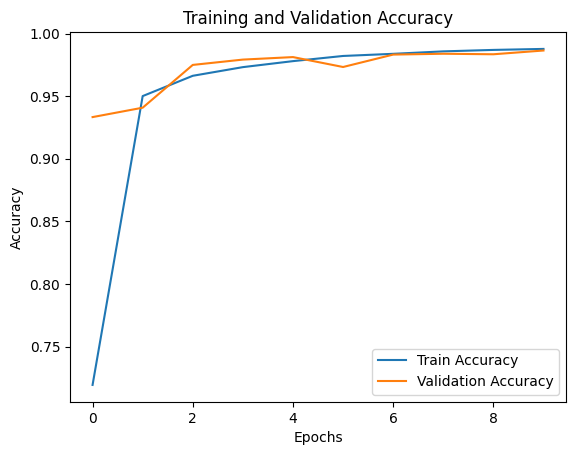

In [ ]:
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

### ResNet on CIFAR-10 Dataset and Comparison of Skip Connections

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
from tensorflow.keras.datasets import cifar10

In [ ]:
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
def residual_block(x, filters, kernel_size=3, downsample=False):
    """Defines a residual block with a skip connection."""
    shortcut = x

    # If downsampling, apply a convolution to the shortcut
    if downsample:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(2, 2), padding='same')(shortcut)
        x = layers.Conv2D(filters, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    else:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

    # Add the skip connection (shortcut)
    x = layers.add([x, shortcut])
    return x

# Build the custom ResNet model
def build_resnet():
    inputs = layers.Input(shape=(32, 32, 3))

    # Initial Conv2D layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)

    # Residual Block 1 (64 filters)
    x = residual_block(x, 64)

    # Residual Block 2 (128 filters, downsampling)
    x = residual_block(x, 128, downsample=True)

    # Residual Block 3 (256 filters, downsampling)
    x = residual_block(x, 256, downsample=True)

    # Global Average Pooling layer
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer
    x = layers.Dense(128, activation='relu')(x)

    # Output layer (10 units for 10 classes, softmax activation)
    outputs = layers.Dense(10, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs, outputs)
    return model

In [ ]:
# Build the model
model = build_resnet()

# Compile the model using Adam optimizer and categorical cross-entropy loss
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 32, 32, 64)     │          1,792 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 32, 32, 64)     │              0 │ conv2d_8[0][0],        │
│                           │                        │                │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 16, 16, 128)    │         73,856 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 16, 16, 128)    │        147,584 │ conv2d_10[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 16, 16, 128)    │          8,320 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 16, 16, 128)    │              0 │ conv2d_11[0][0],       │
│                           │                        │                │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 8, 8, 256)      │        295,168 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 8, 8, 256)      │        590,080 │ conv2d_13[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 8, 8, 256)      │         33,024 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 8, 8, 256)      │              0 │ conv2d_14[0][0],       │
│                           │                        │                │ conv2d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 256)            │              0 │ add_4[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │         32,896 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 10)             │          1,290 │ dense_2[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,257,866 (4.80 MB)

 Trainable params: 1,257,866 (4.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model for 10 epochs
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.2561 - loss: 1.9389 - val_accuracy: 0.4745 - val_loss: 1.4152
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.5250 - loss: 1.3018 - val_accuracy: 0.6001 - val_loss: 1.0971
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.6276 - loss: 1.0302 - val_accuracy: 0.6644 - val_loss: 0.9220
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.6973 - loss: 0.8440 - val_accuracy: 0.7090 - val_loss: 0.8171
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.7409 - loss: 0.7234 - val_accuracy: 0.7606 - val_loss: 0.6916
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.7884 - loss: 0.5997 - val_accuracy: 0.7565 - val_loss: 0.6894
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8206 - loss: 0.5088 - val_accuracy: 0.7841 - val_loss: 0.6231
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8511 - loss: 0.4221 - 

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 2s - 7ms/step - accuracy: 0.7683 - loss: 0.8209

Test accuracy: 0.7682999968528748


In [ ]:
def residual_block_no_skip(x, filters, kernel_size=3, downsample=False):
    """Defines a residual block without a skip connection."""
    if downsample:
        x = layers.Conv2D(filters, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    else:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    return x

# Build the ResNet model without skip connections
def build_resnet_no_skip():
    inputs = layers.Input(shape=(32, 32, 3))

    # Initial Conv2D layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)

    # Residual Block 1 (64 filters)
    x = residual_block_no_skip(x, 64)

    # Residual Block 2 (128 filters, downsampling)
    x = residual_block_no_skip(x, 128, downsample=True)

    # Residual Block 3 (256 filters, downsampling)
    x = residual_block_no_skip(x, 256, downsample=True)

    # Global Average Pooling layer
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer
    x = layers.Dense(128, activation='relu')(x)

    # Output layer (10 units, softmax activation)
    outputs = layers.Dense(10, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs, outputs)
    return model

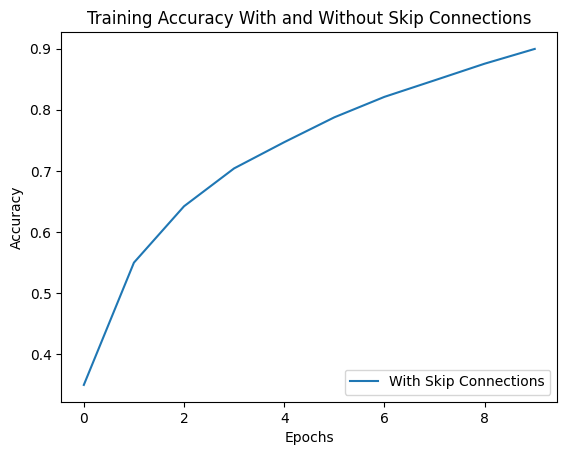

In [ ]:
# Plot training accuracy for both models
plt.plot(history.history['accuracy'], label='With Skip Connections')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training Accuracy With and Without Skip Connections')
plt.show()

### Deeper ResNet and VGG on CIFAR-100 Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-100 dataset
from tensorflow.keras.datasets import cifar100

In [ ]:
# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
def deeper_residual_block(x, filters, kernel_size=3, downsample=False):
    """Defines a residual block with 3 Conv2D layers and a skip connection."""
    shortcut = x

    # Downsample the input if required
    if downsample:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(2, 2), padding='same')(shortcut)
        x = layers.Conv2D(filters, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    else:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

    # Two more Conv2D layers
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

    # Add the skip connection
    x = layers.add([x, shortcut])
    return x

# Build the custom deeper ResNet model
def build_deeper_resnet():
    inputs = layers.Input(shape=(32, 32, 3))

    # Initial Conv2D layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)

    # Residual Block 1 (3 Conv2D layers, 64 filters)
    x = deeper_residual_block(x, 64)

    # Residual Block 2 (3 Conv2D layers, 128 filters, downsampling)
    x = deeper_residual_block(x, 128, downsample=True)

    # Residual Block 3 (3 Conv2D layers, 256 filters, downsampling)
    x = deeper_residual_block(x, 256, downsample=True)

    # Global Average Pooling layer
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer with 256 units
    x = layers.Dense(256, activation='relu')(x)

    # Output layer (100 units for 100 classes, softmax activation)
    outputs = layers.Dense(100, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs, outputs)
    return model

In [ ]:
# Build the model
model = build_deeper_resnet()

# Compile the model using Adam optimizer and categorical cross-entropy loss
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 32, 32, 64)     │          1,792 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ conv2d_15[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ conv2d_17[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 32, 32, 64)     │              0 │ conv2d_18[0][0],       │
│                           │                        │                │ conv2d_15[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 16, 16, 128)    │         73,856 │ add_5[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 16, 16, 128)    │        147,584 │ conv2d_20[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 16, 16, 128)    │        147,584 │ conv2d_21[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 16, 16, 128)    │          8,320 │ add_5[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 16, 16, 128)    │              0 │ conv2d_22[0][0],       │
│                           │                        │                │ conv2d_19[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 8, 8, 256)      │        295,168 │ add_6[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 8, 8, 256)      │        590,080 │ conv2d_24[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 8, 8, 256)      │        590,080 │ conv2d_25[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 8, 8, 256)      │         33,024 │ add_6[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_7 (Add)               │ (None, 8, 8, 256)      │              0 │ conv2d_26[0][0],       │
│                           │                        │                │ conv2d_23[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 256)            │              0 │ add_7[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├──────────────────────

 Total params: 2,089,764 (7.97 MB)

 Trainable params: 2,089,764 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model for 15 epochs
history = model.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.2)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.0344 - loss: 4.3329 - val_accuracy: 0.1095 - val_loss: 3.7437
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.1476 - loss: 3.5538 - val_accuracy: 0.1936 - val_loss: 3.3179
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.2308 - loss: 3.1079 - val_accuracy: 0.2587 - val_loss: 3.0067
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3040 - loss: 2.7348 - val_accuracy: 0.2983 - val_loss: 2.7966
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.3682 - loss: 2.4256 - val_accuracy: 0.3549 - val_loss: 2.5286
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4253 - loss: 2.1407 - val_accuracy: 0.3762 - val_loss: 2.4496
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4861 - loss: 1.8635 - val_accuracy: 0.4019 - val_loss: 2.3695
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5410 - loss: 1.6258 - 

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 5s - 15ms/step - accuracy: 0.4138 - loss: 3.8006

Test accuracy: 0.4138000011444092


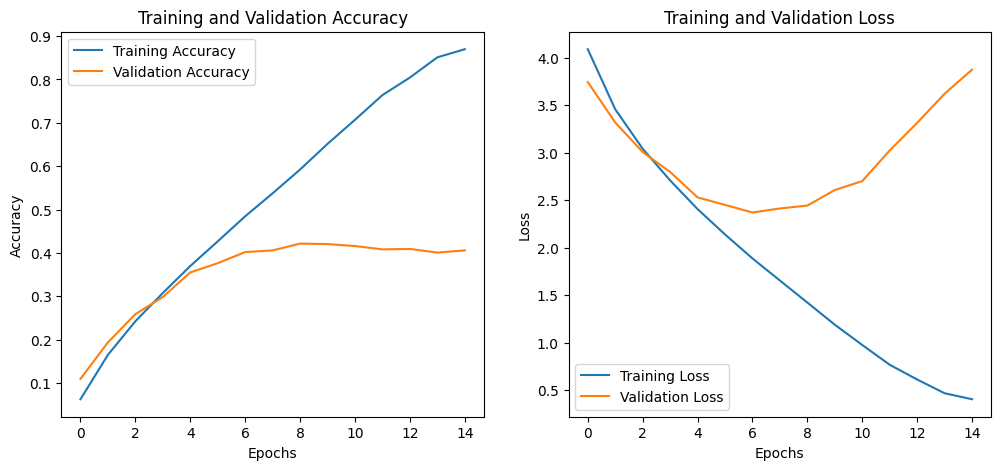

In [ ]:
# Plot training accuracy and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training loss and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [ ]:
def build_vgg():
    model = models.Sequential()

    # Stack of Conv2D layers with MaxPooling
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output from the convolutional layers and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(100, activation='softmax'))  # Output layer for 100 classes

    return model

# Build and compile the VGG model
vgg_model = build_vgg()
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the VGG model
vgg_history = vgg_model.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.2)

# Evaluate the VGG model on the test set
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(x_test, y_test, verbose=2)
print(f'\nVGG Test accuracy: {vgg_test_acc}')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.0320 - loss: 4.3905 - val_accuracy: 0.1131 - val_loss: 3.7384
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.1668 - loss: 3.4944 - val_accuracy: 0.2229 - val_loss: 3.1852
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.2763 - loss: 2.9144 - val_accuracy: 0.2928 - val_loss: 2.8786
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.3588 - loss: 2.5015 - val_accuracy: 0.3314 - val_loss: 2.7160
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4364 - loss: 2.1441 - val_accuracy: 0.3486 - val_loss: 2.6117
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5070 - loss: 1.8325 - val_accuracy: 0.3569 - val_loss: 2.6553
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5845 - loss: 1.5038 - val_accuracy: 0.3613 - val_loss: 2.8323
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6548 - loss: 1.2196 - va

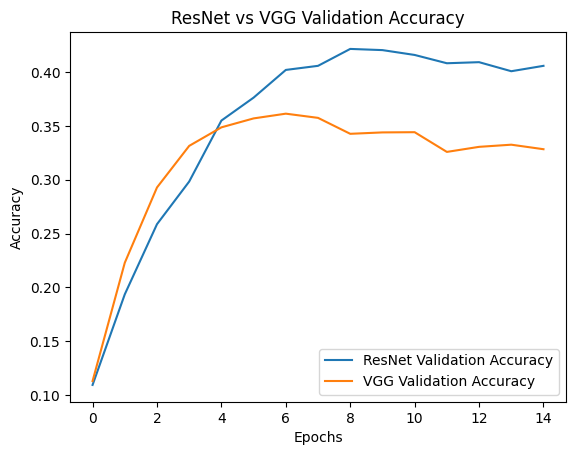

In [ ]:
# Compare accuracy of ResNet and VGG
plt.plot(history.history['val_accuracy'], label='ResNet Validation Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='VGG Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet vs VGG Validation Accuracy')
plt.legend(loc='lower right')
plt.show()